In [16]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# **0. CONTEXTO Y CARGA DATOS**

Fuente: https://github.com/4GeeksAcademy/decision-tree-project-tutorial/blob/main/README.es.md

Descripción de variables: 

- Pregnancies. Número de embarazos del paciente (numérico)

- Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)

- BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)

- SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)

- Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)

- BMI. Índice de masa corporal (numérico)

- DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)

- Age. Edad del paciente (numérico)

- Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

In [4]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **1. CRIBADO MANUAL**

## 1.1. Verificar valores unicos

In [6]:
# Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


## 1.2. Verificar valores duplicados

### 1.2.1. Filas

In [7]:
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

No hay filas duplicadas


### 1.2.2. Columnas

In [8]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

No hay variables exactamente iguales


## 1.3. Verificar missing values

### 1.3.2. Datos enmascarados(numericos)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### 1.3.3. Visualización

In [10]:
#Mostramos columnas con valores nulos
nulos=df.isna().sum()/len(df)*100
nulos[nulos>0.1]

Series([], dtype: float64)

[]

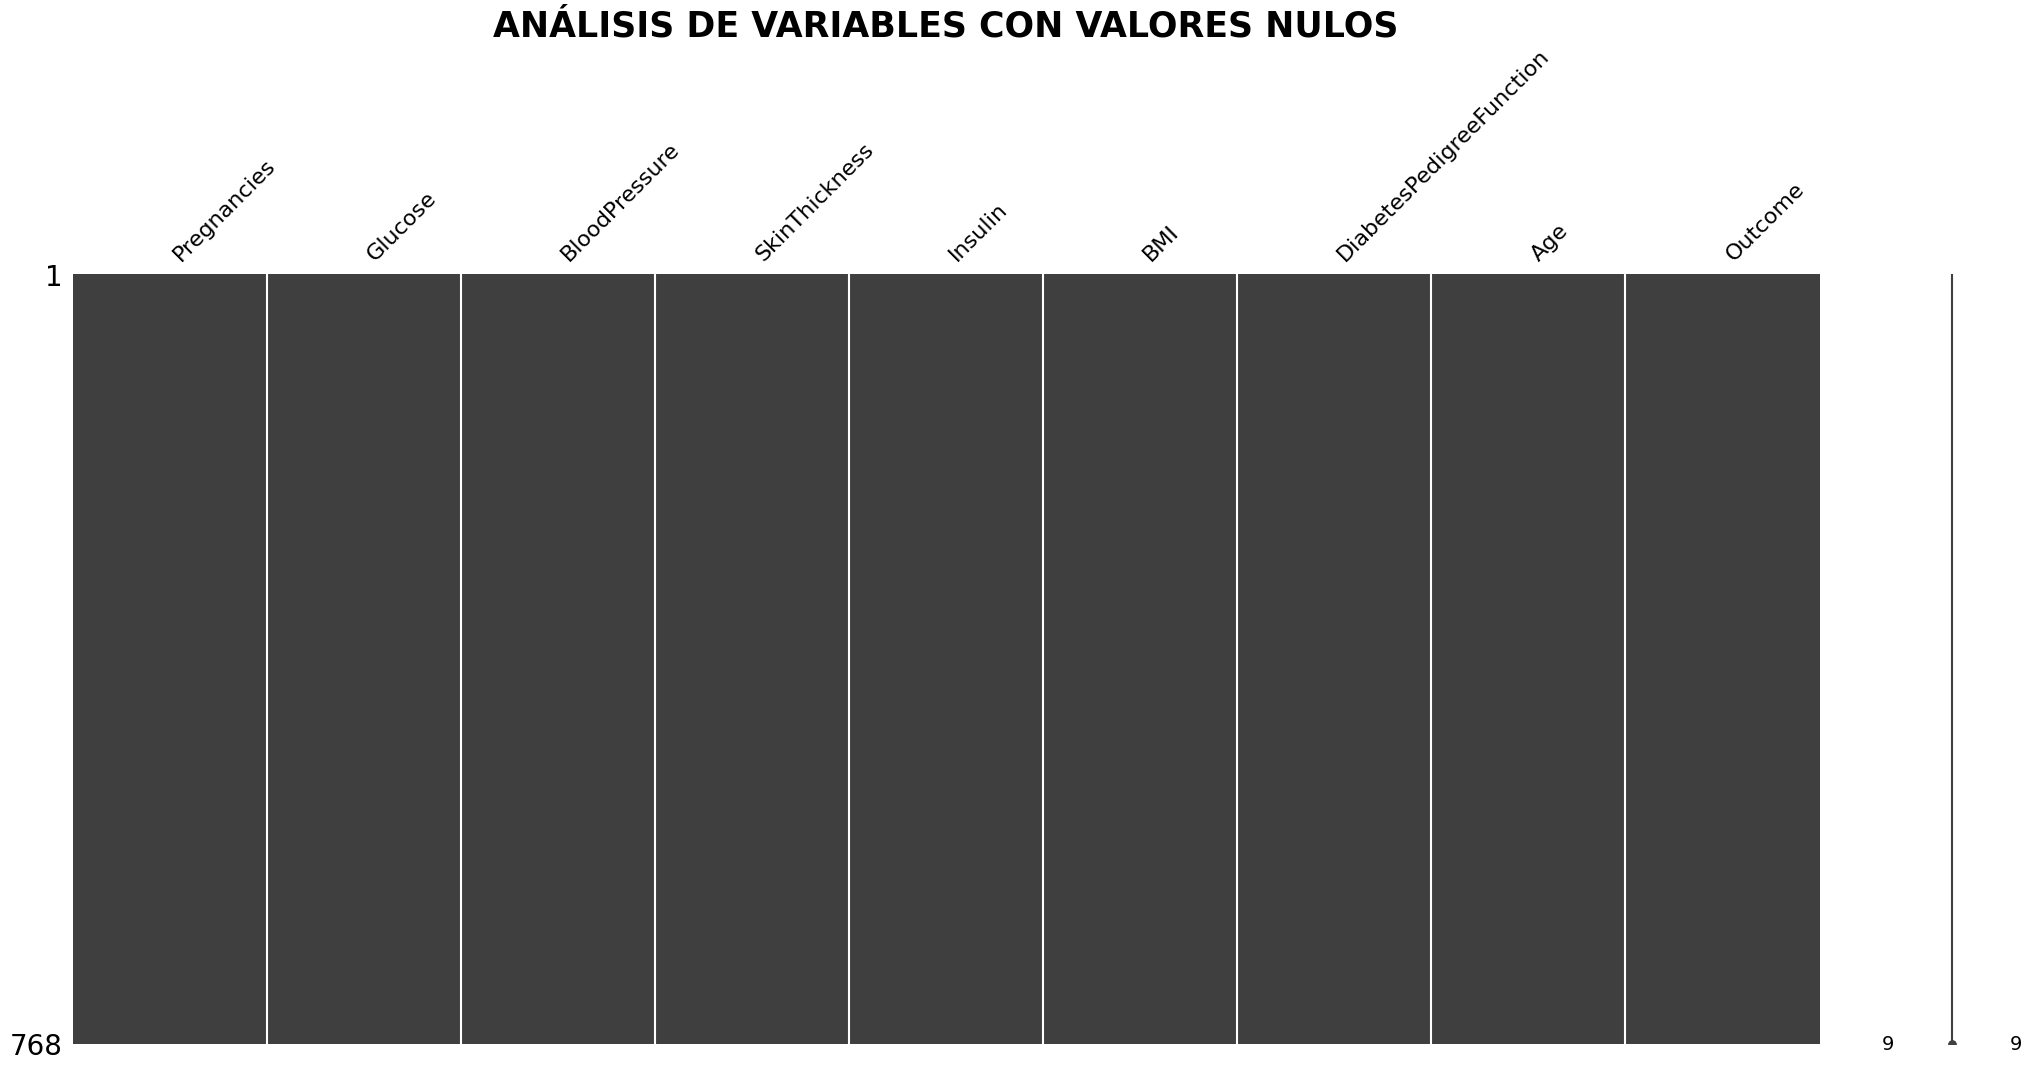

In [15]:
#Gráficamente
msno.matrix(df)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.plot()

## 1.4. División Train-Test

In [18]:
#Diviisón de la base de datos
X = df.drop('Outcome',axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42) #random_state establece una semilla para que la division aleatoria sea la misma
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,0,0,0,0.0,0.304,21
618,9,112,82,24,0,28.2,1.282,50
346,1,139,46,19,83,28.7,0.654,22
294,0,161,50,0,0,21.9,0.254,65
231,6,134,80,37,370,46.2,0.238,46


## 1.7. Análisis de outliers

In [ ]:
#Box Plot

outlier_flag
 1    59.456588
-1    40.543412
Name: proportion, dtype: float64

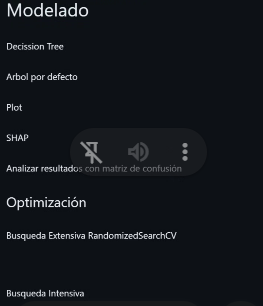